# GCC Insurance Market Exploratory Analysis

### Business Task
Which GCC country should a hypothetical insurer prioritize for expansion, 
and having identified the UAE as a focus market what product-line 
trends should shape their UAE entry strategy?

### Notebook Structure
1. Setup & Load Cleaned Data
2. Cross-GCC Comparison Market Attractiveness
3. UAE Deep Dive Product-Line Trends
4. Key Findings & Recommendation

### Inputs
- `data/cleaned/gcc_merged.csv`
- `data/cleaned/uae_gwp_by_line_usd.csv`

### 1. Setup & Load Cleaned Data

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as patches
import squarify
import seaborn as sns
import numpy as np

PALETTE = {
    "primary": "#0B5394",
    "neutral": "#9AA5B1",
    "accent": "#CFE2F3",
    "text": "#1C1C1C",
    "grid": "#E0E6EB",
}
FIGSIZE = (12, 7)

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": PALETTE["grid"],
    "axes.grid": True,
    "grid.color": PALETTE["grid"],
    "grid.linewidth": 0.6,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "axes.labelweight": "bold",
    "font.family": "sans-serif",
    "font.size": 11,
    "text.color": PALETTE["text"],
    "axes.labelcolor": PALETTE["text"],
    "xtick.color": PALETTE["text"],
    "ytick.color": PALETTE["text"],
    "figure.dpi": 110,
})

gcc = pd.read_csv("data/cleaned/gcc_merged.csv")
uae_lines = pd.read_csv("data/cleaned/uae_gwp_by_line_usd.csv")
worldbank_macro = pd.read_csv("data/cleaned/gcc_worldbank_macro_cleaned.csv")

assert gcc.shape == (6, 13), f"Unexpected GCC shape: {gcc.shape}"
assert uae_lines.shape == (14, 6), f"Unexpected UAE lines shape: {uae_lines.shape}"
assert worldbank_macro.shape == (96, 5), f"Unexpected World Bank shape: {worldbank_macro.shape}"

print("GCC comparison data:", gcc.shape)
print("UAE line-of-business data:", uae_lines.shape)
print("World Bank macro data:", worldbank_macro.shape)

GCC comparison data: (6, 13)
UAE line-of-business data: (14, 6)
World Bank macro data: (96, 5)


### 2. Cross-GCC Comparison Market Attractiveness

Ranking all six GCC countries by insurance penetration (market maturity 
relative to GDP) and density (spend per capita) the two core metrics 
for assessing which market is most attractive for expansion.

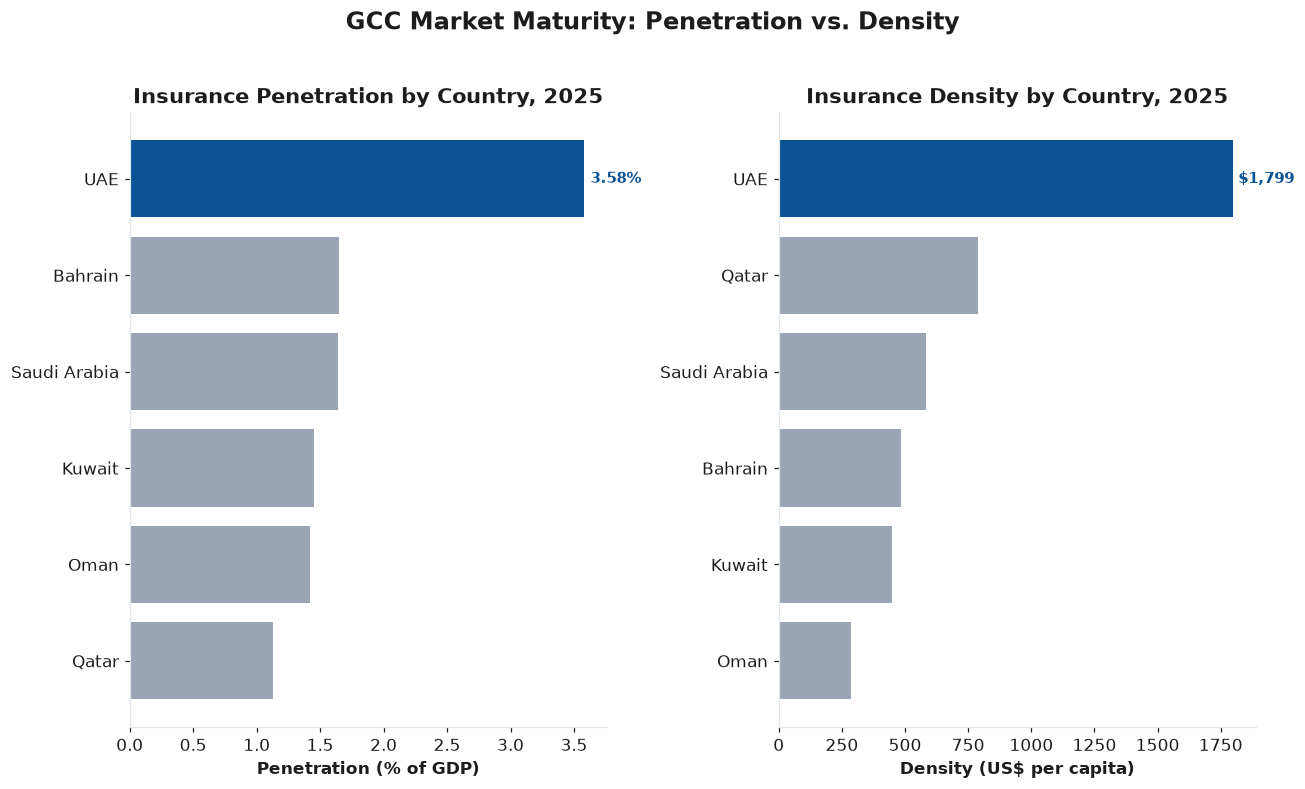

In [13]:
fig, axes = plt.subplots(1, 2, figsize=FIGSIZE)

gcc_sorted_pen = gcc.sort_values("penetration_pct", ascending=False)
colors_pen = [PALETTE["primary"] if i == 0 else PALETTE["neutral"] for i in range(len(gcc_sorted_pen))]
axes[0].barh(gcc_sorted_pen["country"], gcc_sorted_pen["penetration_pct"], color=colors_pen)
axes[0].set_title("Insurance Penetration by Country, 2025")
axes[0].set_xlabel("Penetration (% of GDP)")
axes[0].invert_yaxis()
top_val = gcc_sorted_pen["penetration_pct"].iloc[0]
axes[0].text(top_val + 0.05, 0, f"{top_val}%", va="center", fontsize=10, fontweight="bold", color=PALETTE["primary"])
axes[0].grid(False)

gcc_sorted_den = gcc.sort_values("density_usd", ascending=False)
colors_den = [PALETTE["primary"] if i == 0 else PALETTE["neutral"] for i in range(len(gcc_sorted_den))]
axes[1].barh(gcc_sorted_den["country"], gcc_sorted_den["density_usd"], color=colors_den)
axes[1].set_title("Insurance Density by Country, 2025")
axes[1].set_xlabel("Density (US$ per capita)")
axes[1].invert_yaxis()
top_val_den = gcc_sorted_den["density_usd"].iloc[0]
axes[1].text(top_val_den + 20, 0, f"${top_val_den:,.0f}", va="center", fontsize=10, fontweight="bold", color=PALETTE["primary"])
axes[1].grid(False)

fig.suptitle("GCC Market Maturity: Penetration vs. Density", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("exports/01_maturity.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

### Finding: UAE Leads on Both Maturity Metrics

UAE is the clear leader on both penetration (3.58% of GDP) and density 
($1,799 per capita) roughly double the next-highest country on each 
measure. This signals a mature, saturated insurance market rather than 
an underpenetrated growth opportunity: high penetration and density 
typically indicate a market where insurance adoption is already well 
established, making further growth more about capturing share from 
competitors than expanding a nascent market.

Saudi Arabia, by contrast, sits mid-table on both metrics third of 
six on penetration (1.64%, ahead of Kuwait, Oman, and Qatar) and third 
of six on density ($582 per capita, ahead of Bahrain, Kuwait, and 
Oman) despite being the largest market by total premium volume (see 
next chart). The gap to UAE remains substantial on both measures, 
leaving considerable room to grow toward UAE's level of adoption, even 
though Saudi Arabia is far from the region's least-penetrated market.

### Market Size vs. Growth Potential

Penetration and density show market maturity, but not size or momentum. 
This view plots each country's total GWP (market size) against its GCC 
market share, highlighting where the real volume opportunity lies.

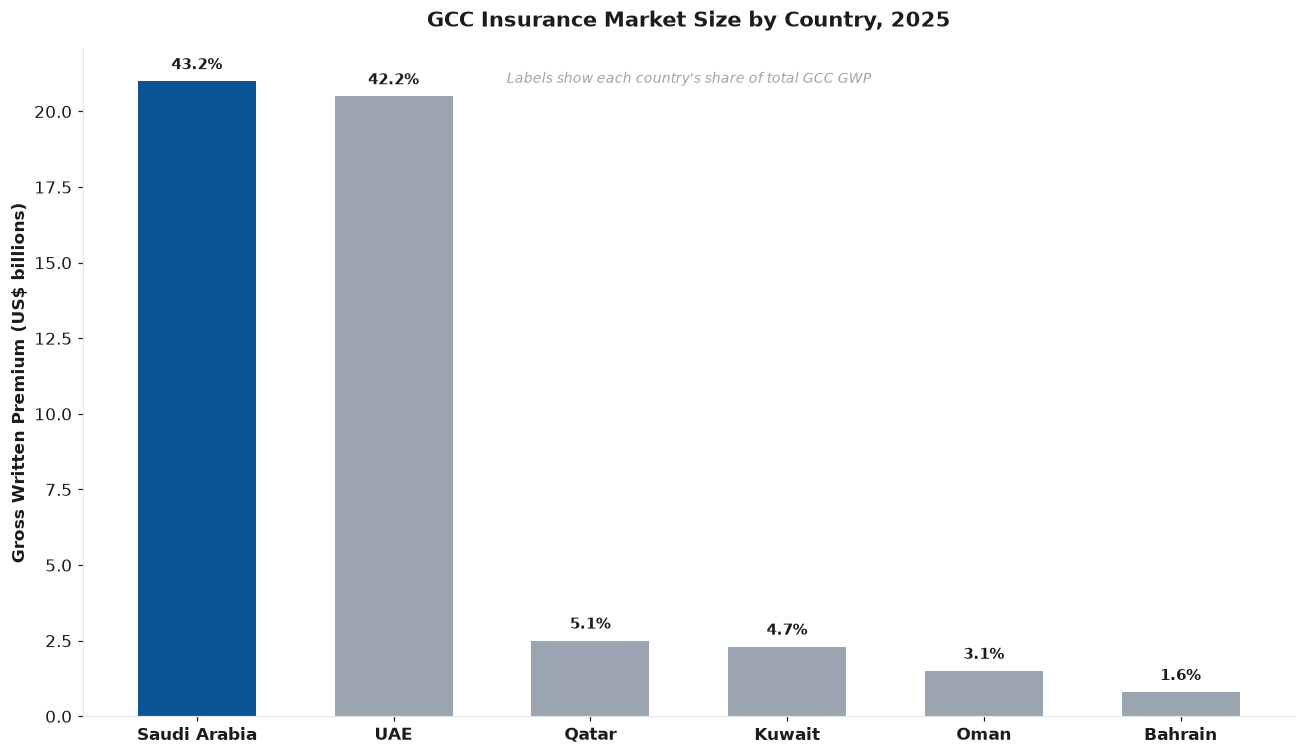

In [14]:
fig, ax = plt.subplots(figsize=FIGSIZE)

gcc_sorted_size = gcc.sort_values("gwp_usd_billion", ascending=False)
colors_size = [PALETTE["primary"] if i == 0 else PALETTE["neutral"] for i in range(len(gcc_sorted_size))]

bars = ax.bar(gcc_sorted_size["country"], gcc_sorted_size["gwp_usd_billion"], color=colors_size, width=0.6)

for label in ax.get_xticklabels():
    label.set_fontweight("bold")

for bar, share in zip(bars, gcc_sorted_size["gcc_share_pct"]):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 0.4, f"{share}%", 
             ha="center", fontsize=10, fontweight="bold", color=PALETTE["text"])

ax.set_title("GCC Insurance Market Size by Country, 2025", pad=15)
ax.set_ylabel("Gross Written Premium (US$ billions)")
ax.set_xlabel("")
ax.text(0.5, 0.95, "Labels show each country's share of total GCC GWP", 
         transform=ax.transAxes, ha="center", fontsize=9, style="italic", color=PALETTE["neutral"])
ax.grid(False)

plt.tight_layout()
plt.savefig("exports/02_market_size.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

### Finding: Two-Country Concentration

Saudi Arabia and UAE together account for 85.4% of total GCC insurance 
premium the remaining four countries combined hold under 15%. Combined 
with the maturity findings above, this frames a clear strategic tension: 
UAE offers the smoother, lower-risk entry (mature, established market, 
already high adoption), while Saudi Arabia offers substantially more 
room for penetration growth, despite lower current density.

### Does Wealth Predict Insurance Adoption?

Plotting penetration against GDP per capita tests whether market 
attractiveness tracks with wealth, or whether some countries are 
underpenetrated despite being wealthy a signal of real, capturable 
opportunity rather than a structural economic constraint.

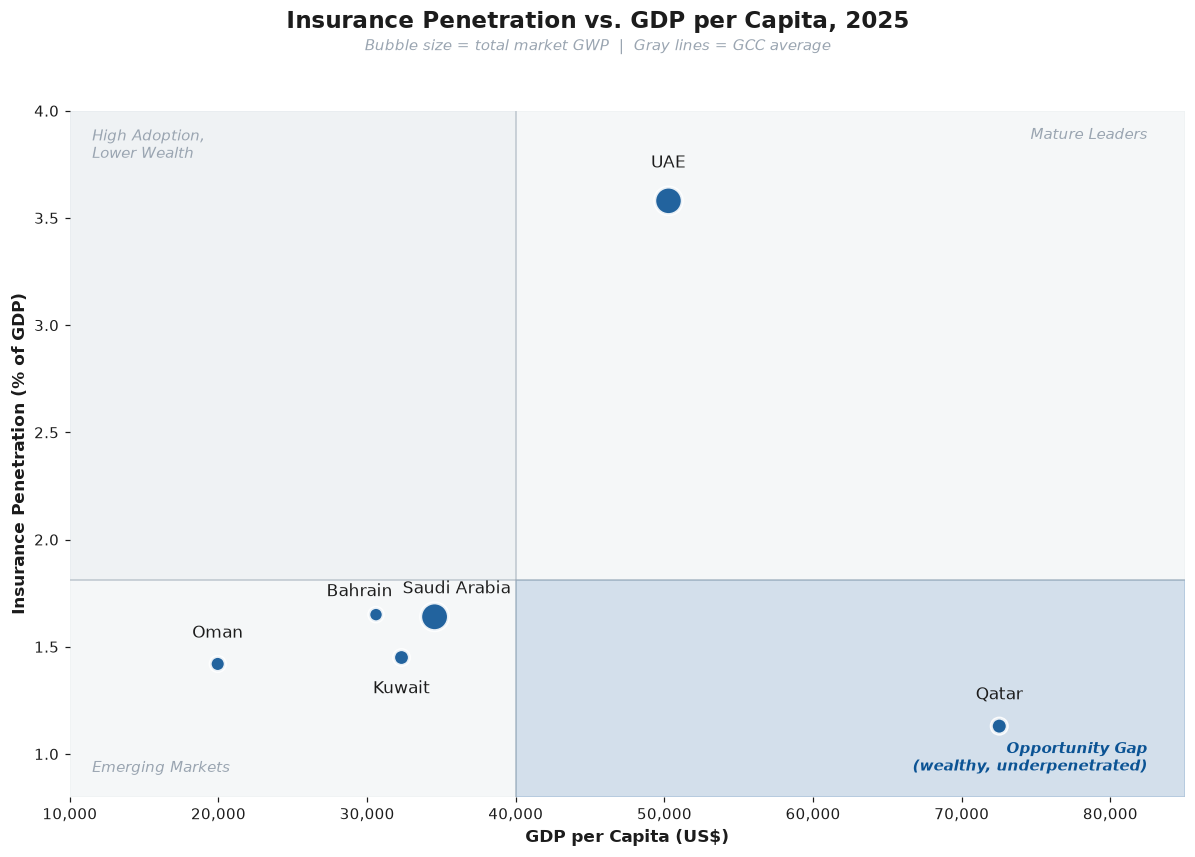

In [15]:
fig, ax = plt.subplots(figsize=(11, 8))

mean_gdp = gcc["gdp_per_capita"].mean()
mean_pen = gcc["penetration_pct"].mean()

xlim = (10000, 85000)
ylim = (0.8, 4.0)
ax.set_xlim(xlim)
ax.set_ylim(ylim)

y_frac = (mean_pen - ylim[0]) / (ylim[1] - ylim[0])


ax.axvspan(xlim[0], mean_gdp, ymin=y_frac, ymax=1, color=PALETTE["grid"], alpha=0.5, zorder=0)      
ax.axvspan(mean_gdp, xlim[1], ymin=y_frac, ymax=1, color=PALETTE["grid"], alpha=0.3, zorder=0)       
ax.axvspan(xlim[0], mean_gdp, ymin=0, ymax=y_frac, color=PALETTE["grid"], alpha=0.3, zorder=0)        
ax.axvspan(mean_gdp, xlim[1], ymin=0, ymax=y_frac, color=PALETTE["primary"], alpha=0.18, zorder=0)    

ax.axvline(mean_gdp, color=PALETTE["neutral"], linewidth=1, alpha=0.5, zorder=1)
ax.axhline(mean_pen, color=PALETTE["neutral"], linewidth=1, alpha=0.5, zorder=1)

sizes = gcc["gwp_usd_billion"] * 12 + 80
ax.scatter(gcc["gdp_per_capita"], gcc["penetration_pct"], 
           s=sizes, color=PALETTE["primary"], alpha=0.9, 
           edgecolors="white", linewidth=2, zorder=3)

directions = {
    "Bahrain": (-0.75, 0.66),
    "Saudi Arabia": (0.75, 0.66),
    "Kuwait": (0.0, -1.0),
}
default_direction = (0.0, 1.0)
LABEL_GAP = 9

for _, row in gcc.iterrows():
    size_val = sizes[gcc["country"] == row["country"]].values[0]
    radius_pts = np.sqrt(size_val / np.pi)
    dx_unit, dy_unit = directions.get(row["country"], default_direction)
    dist = radius_pts + LABEL_GAP
    va = "bottom" if dy_unit > 0 else ("top" if dy_unit < 0 else "center")
    ax.annotate(row["country"], (row["gdp_per_capita"], row["penetration_pct"]),
                xytext=(dx_unit * dist, dy_unit * dist), textcoords="offset points",
                ha="center", va=va, fontsize=11, fontweight="normal", zorder=5)

quad_style = dict(fontsize=9.5, style="italic", fontweight="normal", zorder=2)
ax.text(xlim[0]+1500, ylim[1]-0.08, "High Adoption,\nLower Wealth", ha="left", va="top", color=PALETTE["neutral"], **quad_style)
ax.text(xlim[1]-2500, ylim[1]-0.08, "Mature Leaders", ha="right", va="top", color=PALETTE["neutral"], **quad_style)
ax.text(xlim[0]+1500, ylim[0]+0.1, "Emerging Markets", ha="left", va="bottom", color=PALETTE["neutral"], **quad_style)
ax.text(xlim[1]-2500, ylim[0]+0.1, "Opportunity Gap\n(wealthy, underpenetrated)", ha="right", va="bottom", 
         color=PALETTE["primary"], fontsize=9.5, style="italic", fontweight="bold", zorder=2)

fig.suptitle("Insurance Penetration vs. GDP per Capita, 2025", fontsize=15, fontweight="bold", y=0.97)
fig.text(0.5, 0.925, "Bubble size = total market GWP  |  Gray lines = GCC average", 
          ha="center", fontsize=9.5, style="italic", color=PALETTE["neutral"])

ax.set_xlabel("GDP per Capita (US$)", fontsize=11)
ax.set_ylabel("Insurance Penetration (% of GDP)", fontsize=11)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.tick_params(labelsize=10)
ax.grid(False)
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig("exports/03_quadrant.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

### Finding: Qatar Is the Clear Opportunity Gap

Qatar combines the GCC's highest GDP per capita ($72,525) with its lowest 
insurance penetration (1.13%) a genuine mismatch between wealth and 
insurance adoption, unlike Oman or Kuwait, where low penetration aligns 
with lower wealth. This positions Qatar as the market where insurance 
adoption most clearly lags behind the population's ability to afford it, 
making it a distinct opportunity worth flagging alongside the size-based 
case for Saudi Arabia and the maturity-based case for the UAE.

UAE sits at the opposite extreme high wealth *and* high penetration, 
reflecting a mature, already well-served market. Saudi Arabia and Bahrain 
cluster near the GCC average on both dimensions, while Oman and Kuwait 
sit consistently below average on both, reflecting broadly lower-wealth, 
lower-adoption markets rather than a specific gap.

### GDP per Capita Trends, 2010–2025

The cross-GCC comparison above uses a single-year (2025) snapshot. This 
view adds context: has each country's wealth grown steadily, or is 2025 
an unusual peak or trough?

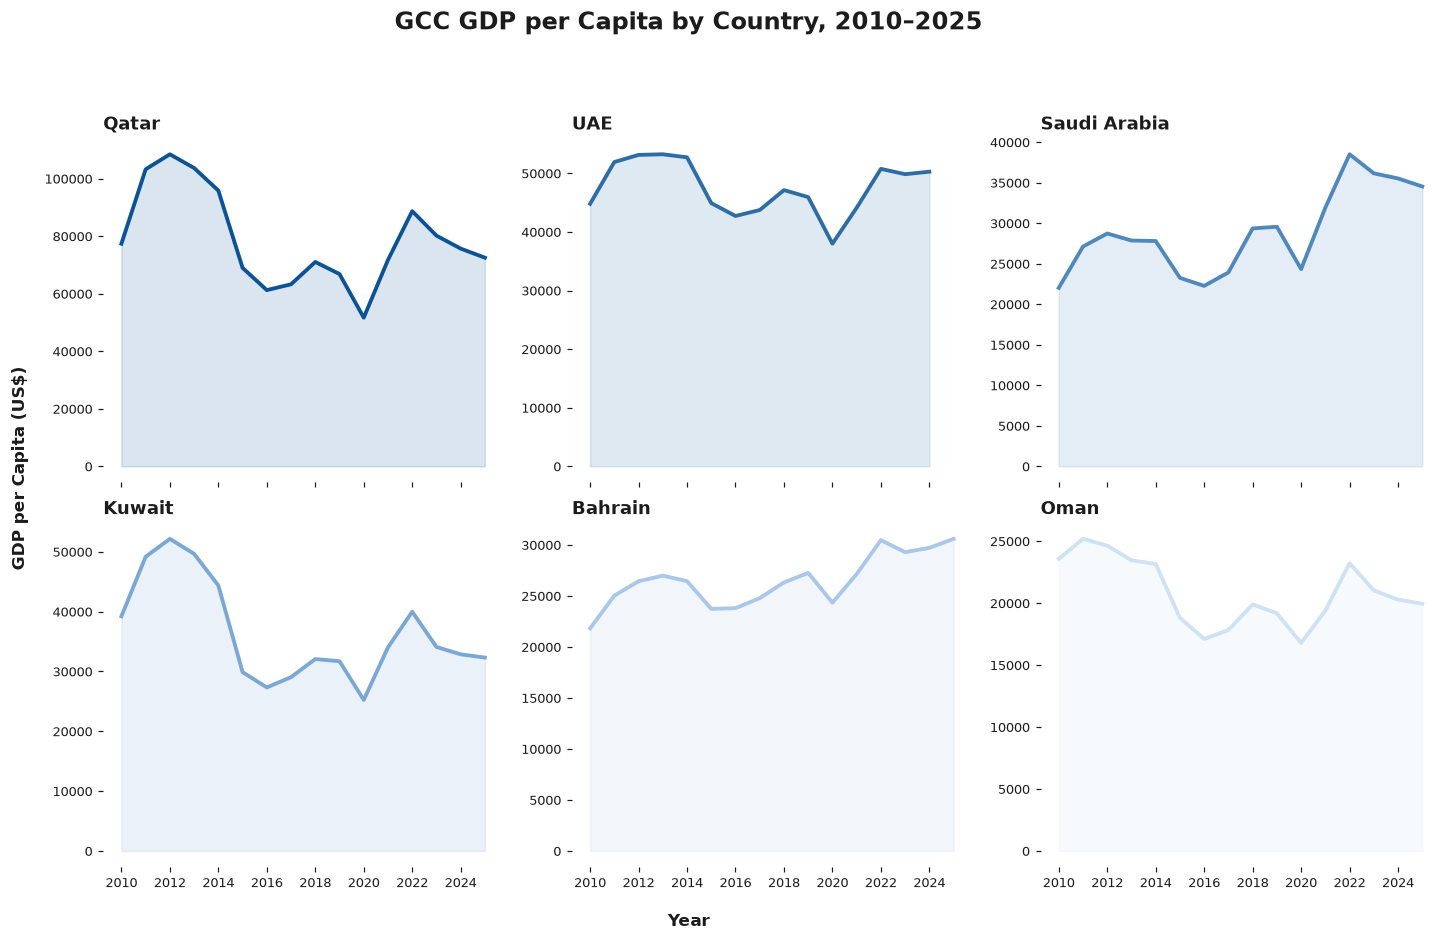

In [16]:
countries_order = worldbank_macro.groupby("country")["gdp_per_capita"].last().sort_values(ascending=False).index.tolist()

n = len(countries_order)
gradient = ["#0B5394", "#2E6DA4", "#5088BC", "#7BA7D4", "#A9C7E8", "#CFE2F3"]
color_map = dict(zip(countries_order, gradient))

fig, axes = plt.subplots(2, 3, figsize=(14, 8), sharex=True)
axes = axes.flatten()

for i, country in enumerate(countries_order):
    subset = worldbank_macro[worldbank_macro["country"] == country].sort_values("year")
    ax = axes[i]
    ax.plot(subset["year"], subset["gdp_per_capita"], color=color_map[country], linewidth=2.5)
    ax.fill_between(subset["year"], subset["gdp_per_capita"], color=color_map[country], alpha=0.15)
    ax.set_title(country, fontsize=12, fontweight="bold", loc="left")
    ax.grid(False)
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.tick_params(labelsize=8.5)

fig.suptitle("GCC GDP per Capita by Country, 2010–2025", fontsize=16, fontweight="bold", y=1.02)
fig.text(0.5, -0.02, "Year", ha="center", fontsize=11, fontweight="bold")
fig.text(0.06, 0.5, "GDP per Capita (US$)", va="center", rotation="vertical", fontsize=11, fontweight="bold")

plt.tight_layout(rect=[0.07, 0, 1, 0.97])
plt.savefig("exports/08_gdp_trends.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

### Finding: Divergent Wealth Trajectories Across the GCC

Splitting each country into its own panel reveals patterns the combined 
view obscured. Qatar and Kuwait both show a pronounced boom (2010–2012) 
followed by a sustained decline through 2016 and continued volatility 
consistent with their heavier historical dependence on hydrocarbon 
export revenue. UAE and Saudi Arabia show comparatively more stable, 
gradually recovering trajectories since 2016. UAE, Saudi Arabia, and 
Bahrain are the only three markets that end the period net higher than 
where they started in 2010, despite each showing meaningful volatility 
along the way; Qatar, Kuwait, and Oman all end 2025 below their 2010 
starting level.

This context reinforces that UAE's current high penetration and density 
(Section 2) sit on a foundation of relatively stable wealth, rather than 
a volatile peak — a meaningfully different risk profile than Qatar's, 
whose current wealth level, while high, has fluctuated significantly 
over the past 15 years.

### Population Growth, 2010–2025

Population growth is a distinct demand driver from wealth growth more 
people means more potential policyholders, regardless of individual 
purchasing power. This ranks each GCC country's population CAGR over 
the same 15-year window.

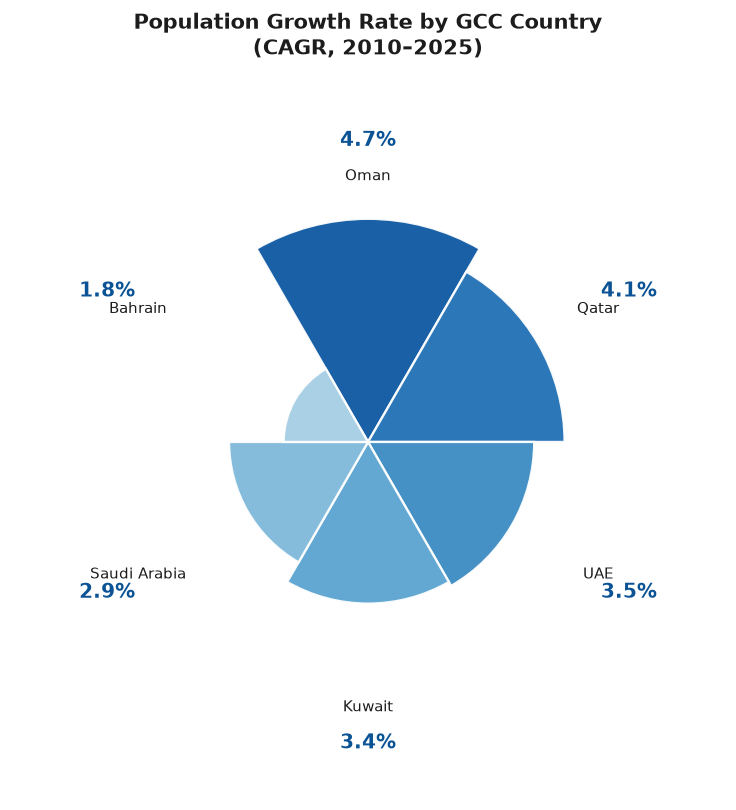

In [17]:
pop_cagr = worldbank_macro.groupby("country").apply(
    lambda g: ((g.loc[g["year"]==2025, "population"].values[0] / g.loc[g["year"]==2010, "population"].values[0]) ** (1/15) - 1) * 100
).sort_values(ascending=False)

n = len(pop_cagr)
angles = np.linspace(0, 2 * np.pi, n, endpoint=False)
max_val = pop_cagr.max()

fig, ax = plt.subplots(figsize=(7.5, 7.5), subplot_kw={"projection": "polar"})
ax.set_theta_zero_location("N")
ax.set_theta_direction(-1)


gradient = plt.cm.Blues(np.linspace(0.85, 0.35, n))


wedge_width = (2 * np.pi / n) * 1.0
ax.bar(angles, pop_cagr.values, width=wedge_width, color=gradient, edgecolor="white", linewidth=1.5, alpha=0.95)

ax.set_xticks([])
ax.set_yticklabels([])
ax.set_ylim(0, max_val * 1.6)
ax.spines["polar"].set_visible(False)
ax.grid(False)


LABEL_RADIUS = max_val * 1.35
for angle, val, country in zip(angles, pop_cagr.values, pop_cagr.index):
    ax.text(angle, LABEL_RADIUS, f"{val:.1f}%", ha="center", va="center", 
             fontsize=13, fontweight="bold", color=PALETTE["primary"])
    ax.text(angle, LABEL_RADIUS - max_val * 0.16, country, ha="center", va="center", 
             fontsize=9.5, fontweight="normal", color=PALETTE["text"])

ax.set_title("Population Growth Rate by GCC Country\n(CAGR, 2010–2025)", pad=20, fontsize=14, fontweight="bold")

plt.savefig("exports/11_population_growth.png", dpi=300, bbox_inches="tight", pad_inches=0.2, facecolor="white")
plt.tight_layout()
plt.show()

### Finding: Oman Leads GCC Population Growth

Oman's population grew at a 4.7% CAGR from 2010–2025, the fastest in 
the GCC a genuinely notable result given Oman ranked lowest on GDP per 
capita, market size, and insurance penetration throughout this analysis 
(Section 2). Qatar (4.1%) and Kuwait (3.4%) follow, while Bahrain (1.8%) 
grew the slowest of the six.

This adds an important nuance to the earlier findings: Oman's weak 
showing on wealth and insurance metrics doesn't reflect a shrinking or 
stagnant market its population base has grown substantially, 
suggesting a growing potential customer base even where current 
insurance penetration hasn't caught up. This is a different kind of 
long-term signal than Qatar's wealth-penetration gap, and worth 
distinguishing in the final recommendation as two separate secondary 
opportunities rather than one.

**Note:** this reflects the 15-year average (CAGR), not current momentum. UAE's 
most recent single-year growth rate is very high (4.8% in 2024 alone, per World 
Bank data) likely reflecting a post-pandemic rebound after a 2020–2021 dip 
but its 15-year average remains lower than Oman's more sustained trajectory 
across the full period.

### Life vs. Non-Life Composition Across the GCC

Comparing each country's product mix shows which markets lean toward 
non-life (motor, health largely mandatory, high-volume) versus life 
insurance (discretionary, typically harder to penetrate). This sets up 
context for the UAE deep dive, where we examine non-life sub-lines in 
much greater detail.

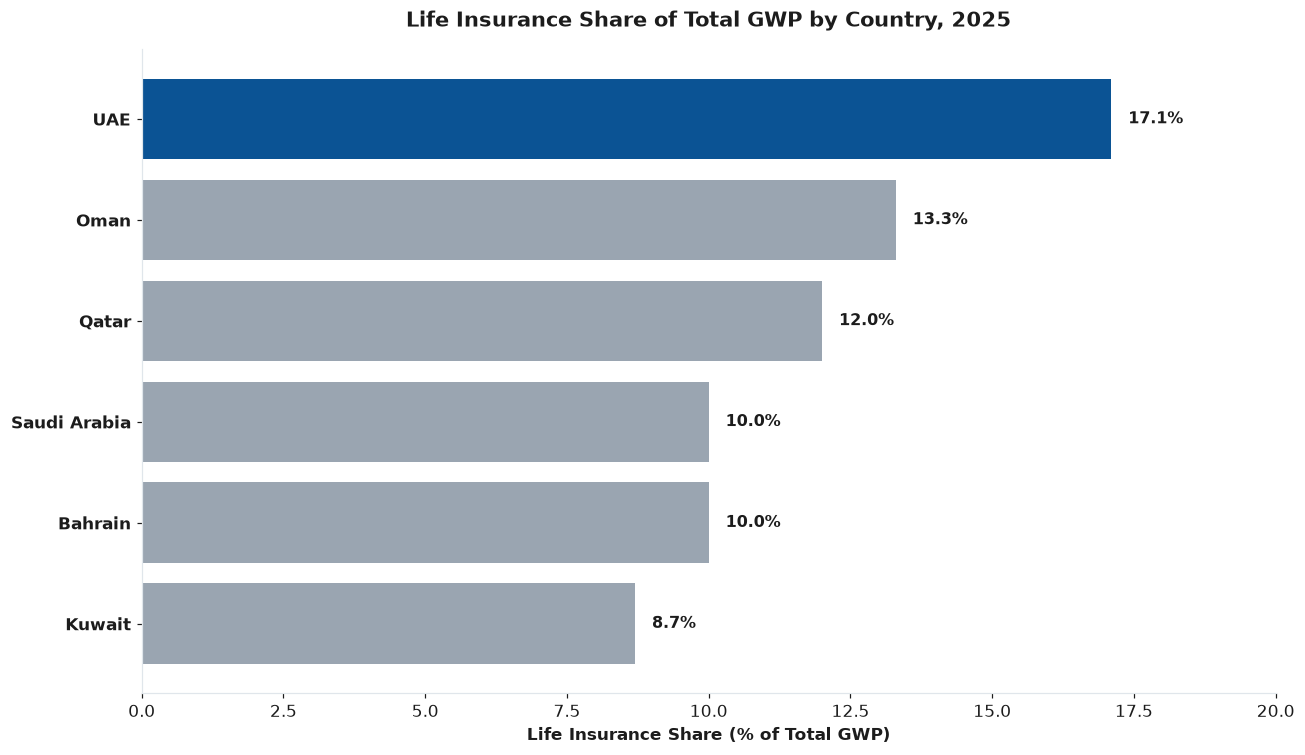

In [18]:
gcc_sorted_mix = gcc.sort_values("life_share_pct", ascending=False)
colors_mix = [PALETTE["primary"] if i == 0 else PALETTE["neutral"] for i in range(len(gcc_sorted_mix))]

fig, ax = plt.subplots(figsize=FIGSIZE)

ax.barh(gcc_sorted_mix["country"], gcc_sorted_mix["life_share_pct"], color=colors_mix)

for i, val in enumerate(gcc_sorted_mix["life_share_pct"]):
    ax.text(val + 0.3, i, f"{val}%", va="center", fontsize=10.5, fontweight="bold", color=PALETTE["text"])

for label in ax.get_yticklabels():
    label.set_fontweight("bold")

ax.set_title("Life Insurance Share of Total GWP by Country, 2025", pad=15)
ax.set_xlabel("Life Insurance Share (% of Total GWP)")
ax.set_ylabel("")
ax.invert_yaxis()
ax.set_xlim(0, 20)
ax.grid(False)

plt.tight_layout()
plt.savefig("exports/04_life_share.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

### Finding: UAE Leads on Life Insurance Uptake Too

UAE has the highest life insurance share of any GCC market (17.1%), 
nearly double Kuwait's (8.7%), the lowest. This reinforces the earlier 
finding that UAE is the most mature, diversified insurance market in 
the region: not only does it lead on overall penetration and density, 
but its product mix also appears more balanced between life and 
non-life than most other GCC markets, which remain more heavily 
dependent on mandatory non-life lines like motor and health.

Note: this 17.1% figure comes from Alpen Capital's regional dataset. 
CBUAE's more granular UAE-specific data (used in the deep-dive sections 
below) implies a lower life share of roughly 11.2% a discrepancy 
between the two sources that isn't fully reconciled (see Limitations, cell 37). UAE's relative 
lead over other GCC markets on this metric holds directionally under 
either reading, but the size of that lead is less certain than the 
headline figure alone suggests.

### UAE Market Composition, 2025

Before examining growth trends, this treemap shows the full relative 
size of every UAE insurance line in a single snapshot.

### 3. UAE Deep Dive Product Line Trends

Having identified the UAE as the priority market (mature, high-adoption, 
diversified), this section examines which specific product lines have 
driven its growth from 2021–2025, and which should shape entry strategy.

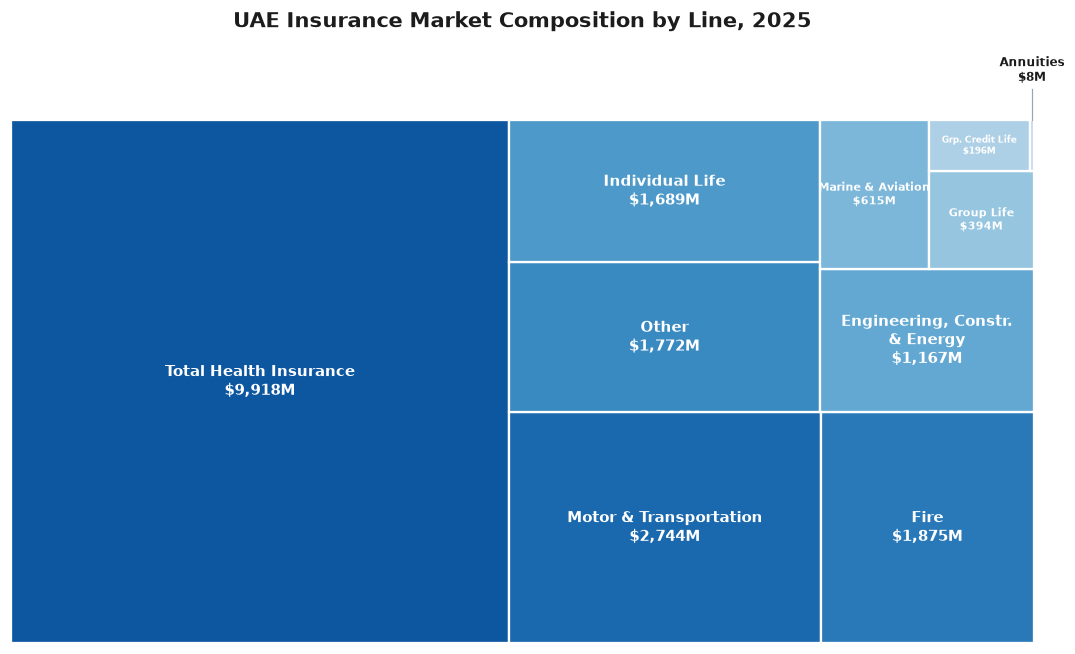

Verified — Health 2025: $9,918M


In [19]:
individual_lines = ["Fire", "Marine & Aviation", "Motor & Transportation", 
                     "Engineering Construction & Energy", "Other",
                     "Total Health Insurance", "Group Life", "Group Credit Life", 
                     "Individual Life", "Annuities & Fund Accumulation"]

display_names = {
    "Group Credit Life": "Grp. Credit Life",
    "Annuities & Fund Accumulation": "Annuities",
    "Engineering Construction & Energy": "Engineering, Constr.\n& Energy",
}

tree_data = uae_lines[uae_lines["line_of_business"].isin(individual_lines)].sort_values("2025", ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=FIGSIZE)

n = len(tree_data)
shades = plt.cm.Blues([0.85 - i*0.65/n for i in range(n)])

WIDTH, HEIGHT = 100, 60
sizes_norm = squarify.normalize_sizes(tree_data["2025"], WIDTH, HEIGHT)
rects = squarify.squarify(sizes_norm, 0, 0, WIDTH, HEIGHT)

EXTERNAL_LABEL_THRESHOLD = 4

for i, (rect, color) in enumerate(zip(rects, shades)):
    row = tree_data.iloc[i]
    line_name = row["line_of_business"]
    value_2025 = row["2025"]

    ax.add_patch(patches.Rectangle((rect["x"], rect["y"]), rect["dx"], rect["dy"], 
                                     facecolor=color, edgecolor="white", linewidth=1.5))
    cell_min_dim = min(rect["dx"], rect["dy"])
    name = display_names.get(line_name, line_name)
    cx, cy = rect["x"] + rect["dx"]/2, rect["y"] + rect["dy"]/2

    if cell_min_dim < EXTERNAL_LABEL_THRESHOLD:
        label_y = rect["y"] + rect["dy"] + 4
        ax.plot([cx, cx], [rect["y"] + rect["dy"], label_y - 0.5], color=PALETTE["neutral"], linewidth=0.8)
        ax.text(cx, label_y, f"{name}\n${value_2025:,.0f}M", ha="center", va="bottom", 
                 fontsize=8, color=PALETTE["text"], fontweight="bold")
    else:
        fontsize = max(6, min(10, cell_min_dim * 0.7))
        ax.text(cx, cy, f"{name}\n${value_2025:,.0f}M", ha="center", va="center", 
                 fontsize=fontsize, color="white", fontweight="bold")

ax.set_xlim(0, WIDTH)
ax.set_ylim(0, HEIGHT + 8)
ax.set_title("UAE Insurance Market Composition by Line, 2025", pad=15)
ax.axis("off")

assert tree_data["2025"].iloc[0] == tree_data["2025"].max(), "Treemap not using correct 2025 values"

plt.savefig("exports/09_treemap.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()
print("Verified — Health 2025:", f"${tree_data[tree_data['line_of_business']=='Total Health Insurance']['2025'].values[0]:,.0f}M")

### Finding: Health Dominates the UAE Market Composition

Health insurance alone accounts for USD 9,918M  nearly half (48.7%) of UAE's total 2025 market  dwarfing every other individual line. Motor & Transportation (USD 2,744M) is the second-largest single line, ahead of Fire (USD 1,875M), the unspecified "Other" category (USD 1,772M), and Individual Life (USD 1,689M). The remaining five named lines Engineering, Constr. & Energy (USD 1,167M), Marine & Aviation (USD 615M), Group Life (USD 394M), Group Credit Life (USD 196M), and Annuities (USD 8M) each represent under 6% of the total market individually.

This composition confirms the earlier growth trend finding: Health and Motor aren't just the fastest growing lines (Section 3), they are also, by a wide margin, the two largest by absolute size  reinforcing them as the clear priority lines for a UAE market entry strategy.

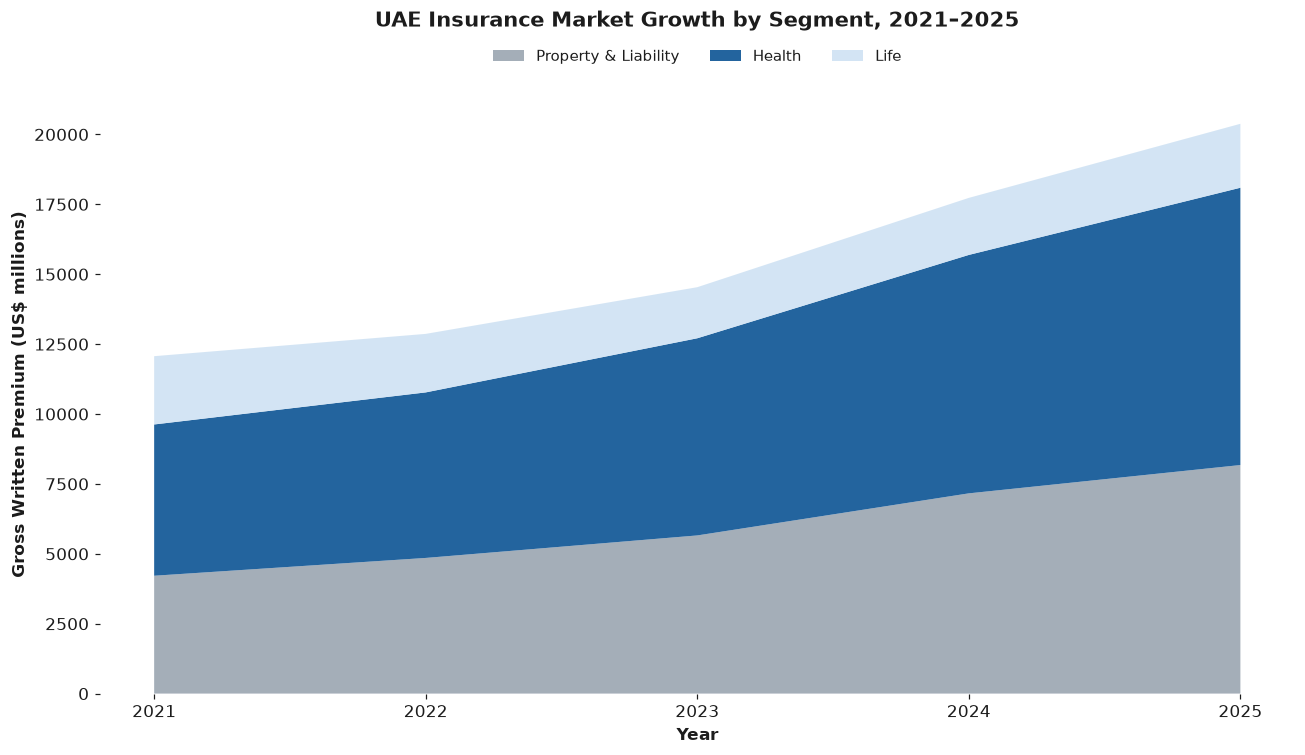

In [20]:
years = ["2021", "2022", "2023", "2024", "2025"]
segments = ["Total Property & Liability", "Total Health Insurance", "Total Life"]

seg_data = uae_lines[uae_lines["line_of_business"].isin(segments)].set_index("line_of_business")[years]

fig, ax = plt.subplots(figsize=FIGSIZE)

colors_seg = [PALETTE["neutral"], PALETTE["primary"], PALETTE["accent"]]
ax.stackplot(years, seg_data.loc["Total Property & Liability"], 
              seg_data.loc["Total Health Insurance"], 
              seg_data.loc["Total Life"],
              labels=["Property & Liability", "Health", "Life"],
              colors=colors_seg, alpha=0.9)

ax.set_title("UAE Insurance Market Growth by Segment, 2021–2025", pad=45)
ax.set_xlabel("Year", fontweight="bold")
ax.set_ylabel("Gross Written Premium (US$ millions)")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, 1.10), ncol=3, frameon=False, fontsize=10)
ax.grid(False)
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.savefig("exports/05_uae_growth.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

### Finding: Health Insurance Is the Primary Growth Engine

UAE's total insurance market grew from USD 12.1B in 2021 to USD 20.4B in 2025 (a 69% increase over five years). Health insurance has been the largest and fastest expanding segment throughout, growing 83% from USD 5.4B to USD 9.9B now accounting for nearly half of total market GWP. Property & Liability grew steadily as well (from USD 4.2B to USD 8.2B), while Life insurance is the only segment that declined, falling 6.4% from USD 2,442M to USD 2,287M and now representing the smallest of the three segments in absolute terms — a drop driven by Annuities (-73.5%), Group Credit Life (-24%), and Individual Life (-12.4%), only partly offset by Group Life's growth (+73.9%). This stands in contrast to UAE's regional position, where it holds the GCC's highest life insurance *share* (Section 2) despite this domestic decline.

This points to health insurance as the dominant driver of UAE market growth, likely reflecting the phased rollout of mandatory health insurance across the emirates over this period.

### Property & Liability Sub-Line Trends

Breaking down the Property & Liability segment into its individual lines 
reveals which specific products are driving growth versus which are 
stagnant critical detail for shaping which non-life products to lead 
within a UAE entry strategy.

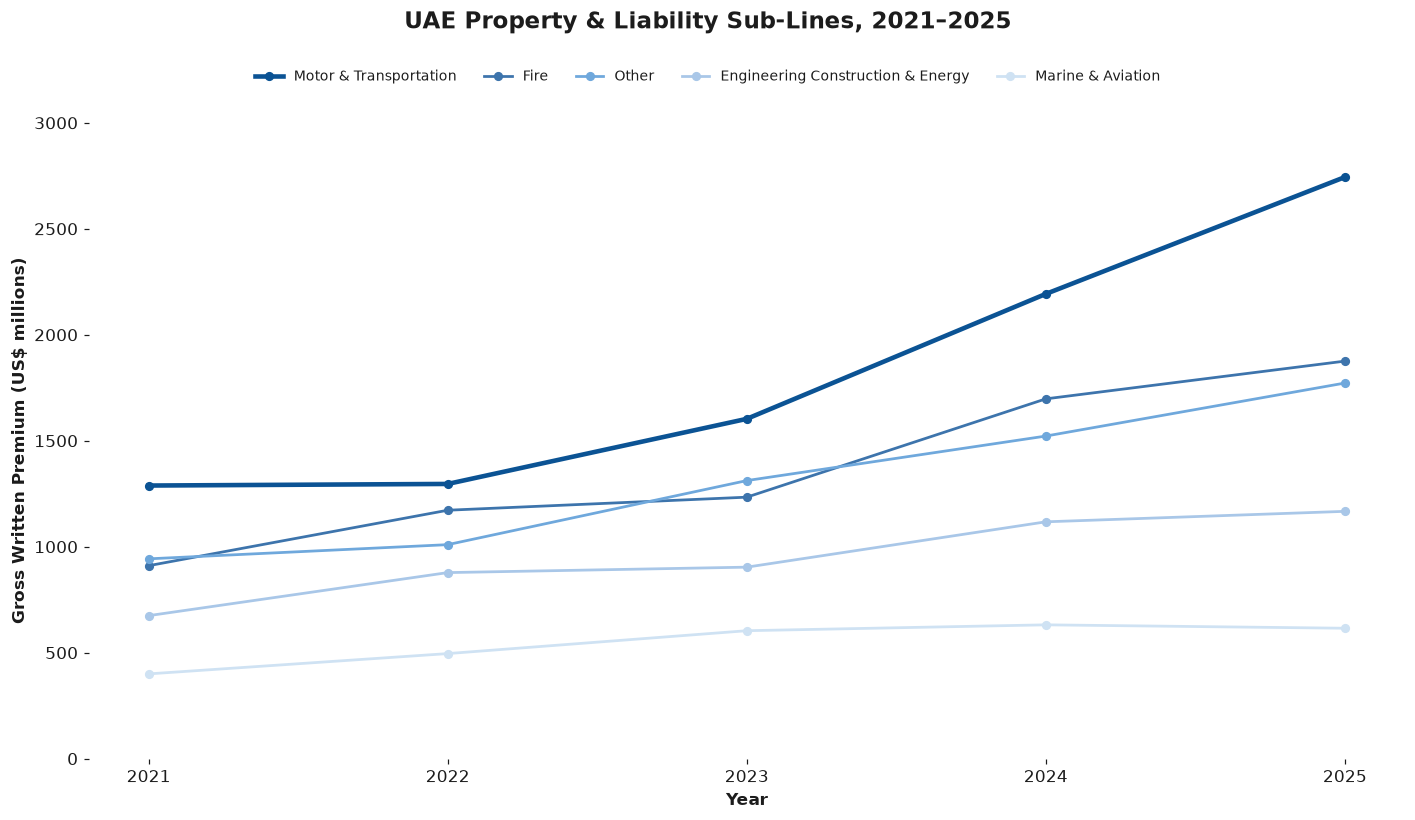

In [21]:
years = ["2021", "2022", "2023", "2024", "2025"]
sublines = ["Fire", "Marine & Aviation", "Motor & Transportation", 
            "Engineering Construction & Energy", "Other"]

sublines_sorted = sorted(sublines, key=lambda l: uae_lines[uae_lines["line_of_business"] == l]["2025"].iloc[0], reverse=True)

gradient_colors = [
    "#0B5394",
    "#3D74AC",
    "#6FA8DC",
    "#A9C7E8",
    "#CFE2F3",
]
color_map = dict(zip(sublines_sorted, gradient_colors))

fig, ax = plt.subplots(figsize=(13, 7))

for line in sublines_sorted:
    row = uae_lines[uae_lines["line_of_business"] == line][years].iloc[0]
    lw = 3 if line == sublines_sorted[0] else 1.8
    ax.plot(years, row, marker="o", markersize=5, color=color_map[line], linewidth=lw, label=line)

ax.set_ylim(0, 3000)

fig.suptitle("UAE Property & Liability Sub-Lines, 2021–2025", fontsize=15, fontweight="bold", y=1.06)
fig.legend(loc="upper center", bbox_to_anchor=(0.5, 1.0), ncol=5, frameon=False, fontsize=9)

ax.set_xlabel("Year", fontweight="bold")
ax.set_ylabel("Gross Written Premium (US$ millions)")
ax.grid(False)
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.savefig("exports/06_pl_sublines.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

### Finding: Motor Insurance Is the Standout Growth Line

Motor & Transportation grew from USD 1.29B (2021) to USD 2.74B (2025) a 113% increase, and by far the largest absolute growth of any Property & Liability sub-line. It has been the largest non-life line throughout the period, ahead of Fire in every year from 2021 onward, and has pulled further ahead since. Engineering and "Other" show steady, moderate growth, while Marine & Aviation has remained comparatively flat throughout the period the smallest and slowest growing sub-line.

Combined with the earlier finding that Health is the dominant overall growth driver, this suggests **Health and Motor together** should be the priority product lines for a UAE market entry strategy both are large, fast-growing, and likely benefit from mandatory-insurance regulatory tailwinds (health coverage mandates, motor insurance enforcement).

### Life Insurance Sub-Line Trends

Breaking down the Life segment reveals a less straightforward growth 
story than Property & Liability, useful context on where the 
smaller but highest share (Section 2) life segment is actually 
finding demand.

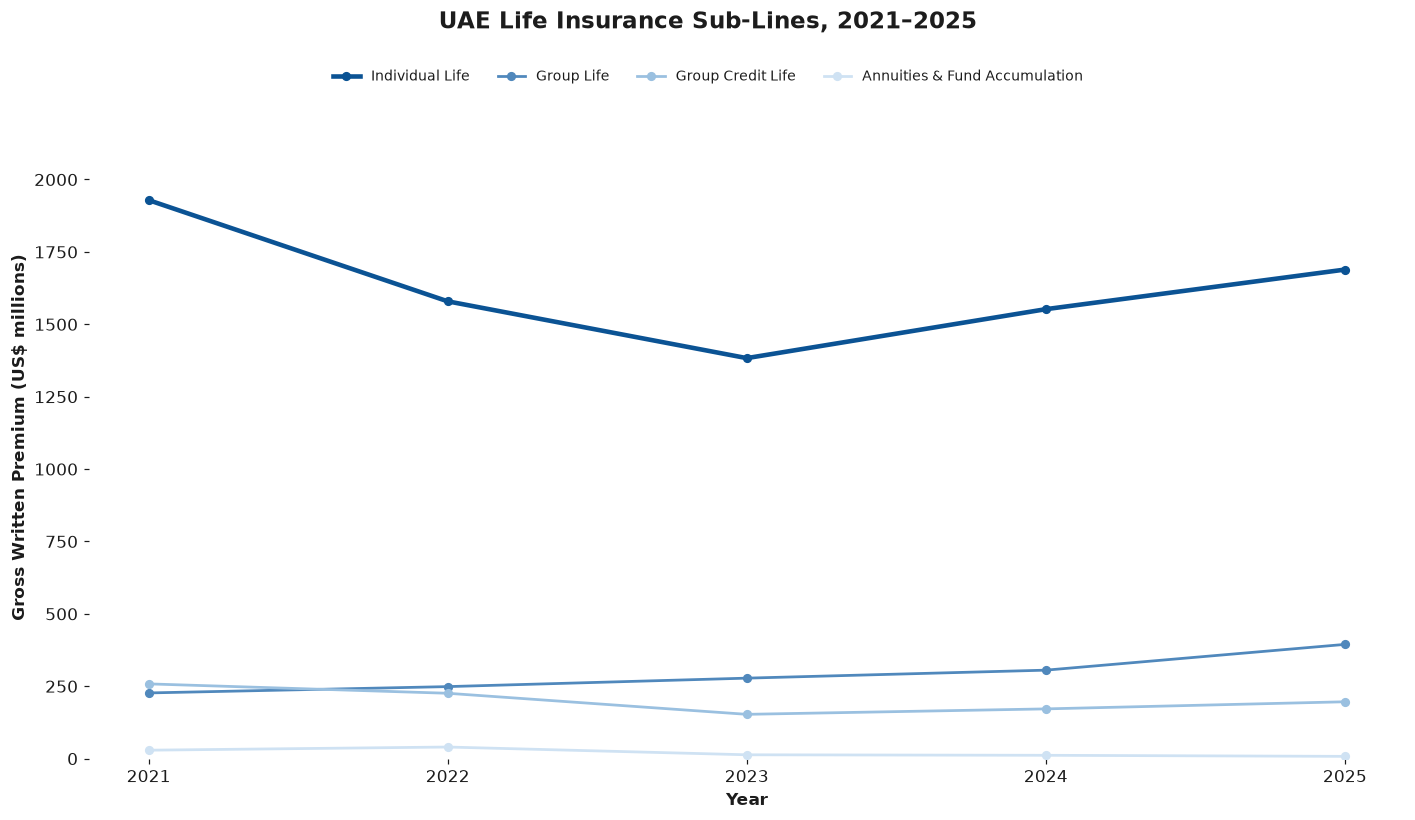

In [22]:
life_sublines = ["Individual Life", "Group Life", "Group Credit Life", "Annuities & Fund Accumulation"]

life_sorted = sorted(life_sublines, key=lambda l: uae_lines[uae_lines["line_of_business"] == l]["2025"].iloc[0], reverse=True)

gradient_colors_4 = ["#0B5394", "#5088BC", "#9AC0E0", "#CFE2F3"]
color_map_life = dict(zip(life_sorted, gradient_colors_4))

fig, ax = plt.subplots(figsize=(13, 7))

for line in life_sorted:
    row = uae_lines[uae_lines["line_of_business"] == line][years].iloc[0]
    lw = 3 if line == life_sorted[0] else 1.8
    ax.plot(years, row, marker="o", markersize=5, color=color_map_life[line], linewidth=lw, label=line)

ax.set_ylim(0, max(uae_lines[uae_lines["line_of_business"] == life_sorted[0]][years].iloc[0]) * 1.15)

fig.suptitle("UAE Life Insurance Sub-Lines, 2021–2025", fontsize=15, fontweight="bold", y=1.06)
fig.legend(loc="upper center", bbox_to_anchor=(0.5, 1.0), ncol=4, frameon=False, fontsize=9)

ax.set_xlabel("Year", fontweight="bold")
ax.set_ylabel("Gross Written Premium (US$ millions)")
ax.grid(False)
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.savefig("exports/07_life_sublines.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

### Finding: Individual Life's Dip and Recovery Pattern

Individual Life, the largest life sub-line by far, shows a distinctly different pattern from every other line examined so far: it declined from USD 1.93B (2021) to a low of USD 1.38B (2023), a 28% drop, before recovering to USD 1.69B by 2025. This dip-then-recovery shape is unique across the whole dataset; every Property & Liability sub-line and Health insurance grew steadily throughout the same period with no comparable downturn.

Group Life, in contrast, has grown steadily and consistently throughout (from USD 227M to USD 394M, +74%), while Group Credit Life and Annuities & Fund Accumulation remain small and comparatively flat.

### UAE Growth Rates by Line, 2021–2025

Ranking every UAE sub-line by its 2021–2025 CAGR, rather than absolute 
GWP, isolates which lines grew fastest regardless of starting size.

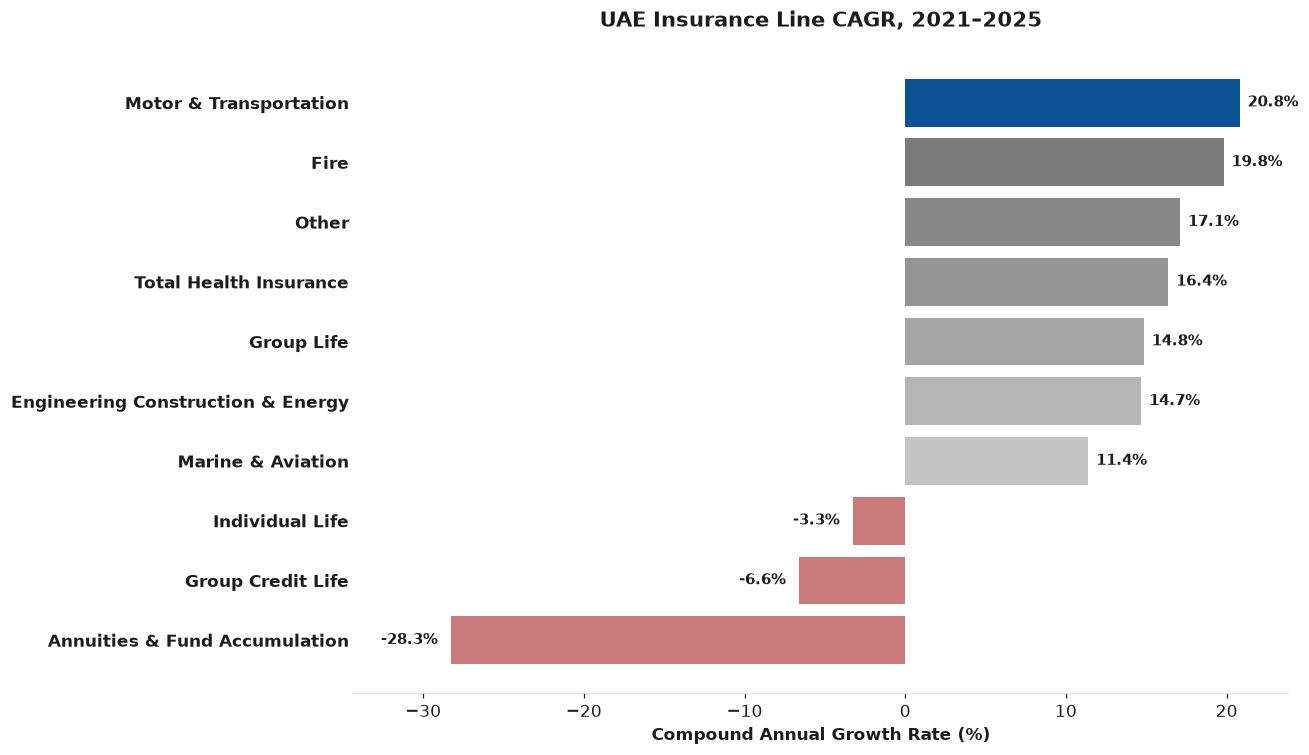

In [23]:
cagr_data = uae_lines[uae_lines["line_of_business"].isin(individual_lines)].copy()
cagr_data["cagr_pct"] = ((cagr_data["2025"] / cagr_data["2021"]) ** (1/4) - 1) * 100
cagr_data = cagr_data.sort_values("cagr_pct", ascending=True)

positive_mask = cagr_data["cagr_pct"] > 0
n_positive = positive_mask.sum()
gray_shades = plt.cm.Greys(np.linspace(0.35, 0.6, n_positive - 1))  

colors_cagr = []
pos_idx = 0
for i, val in enumerate(cagr_data["cagr_pct"]):
    if val <= 0:
        colors_cagr.append("#C97B7B")  
    elif i == len(cagr_data) - 1:
        colors_cagr.append(PALETTE["primary"])  
    else:
        colors_cagr.append(gray_shades[pos_idx])
        pos_idx += 1

fig, ax = plt.subplots(figsize=FIGSIZE)
ax.spines["left"].set_visible(False)
ax.tick_params(axis="y", length=0)
ax.barh(cagr_data["line_of_business"], cagr_data["cagr_pct"], color=colors_cagr)
ax.set_xlim(cagr_data["cagr_pct"].min() - 6, cagr_data["cagr_pct"].max() + 3)
ax.spines["left"].set_visible(False)
ax.tick_params(axis="y", length=0)

for i, val in enumerate(cagr_data["cagr_pct"]):
    if val >= 0:
        ax.text(val + 0.5, i, f"{val:.1f}%", va="center", ha="left", fontsize=9.5, fontweight="bold", color=PALETTE["text"])
    else:
        ax.text(val - 0.8, i, f"{val:.1f}%", va="center", ha="right", fontsize=9.5, fontweight="bold", color=PALETTE["text"])
        
for label in ax.get_yticklabels():
    label.set_fontweight("bold")

ax.set_title("UAE Insurance Line CAGR, 2021–2025", pad=15)
ax.set_xlabel("Compound Annual Growth Rate (%)")
ax.grid(False)

plt.savefig("exports/10_cagr_ranking.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.tight_layout()
plt.show()

### Finding: Motor Confirmed as Top Performer on Both Measures

Motor & Transportation leads on CAGR (20.8%) as well as absolute growth 
(Section 3), confirming it as the standout line by any measure not an 
artifact of starting from a small base. Fire (19.8%) and Other (17.1%) 
follow closely, while Health, despite its dominant absolute size 
(Section 3 treemap), grows at a more moderate 16.4% CAGR still strong, 
but not the fastest-growing line on a rate basis.

The three declining lines are all life sub-products: Annuities & Fund 
Accumulation (-28.3%), Group Credit Life (-6.6%), and Individual Life 
(-3.3%). This aligns with the earlier finding that individual/retail 
life products underperformed group products over this period and 
shows the decline is broader than Individual Life alone, extending to 
annuities and credit-linked life products as well.

**Combined implication:** Motor, Fire, and Health represent the 
strongest non-life growth opportunities by both size and rate, while 
any life insurance strategy should lean toward group products and 
treat individual/retail life, credit life, and annuities as segments 
requiring more caution.

### 4. Key Findings & Recommendation

### Summary of Evidence

**Cross-GCC Comparison (Section 2):**
- UAE leads the GCC on both insurance penetration (3.58%) and density 
  ($1,799.3) roughly double the next-highest country on each metric  
  indicating a mature, well-established market
- Saudi Arabia and UAE together account for 85.4% of total GCC insurance 
  premium; Saudi Arabia is the largest single market, reflecting a 
  still-developing market with more room to expand than UAE.
- UAE also has the highest life insurance share of any GCC market on 
  Alpen Capital's regional data (17.1%), suggesting the most diversified 
  product mix in the region though CBUAE's UAE-specific data implies a 
  lower life share (~11.2%), a cross-source discrepancy that isn't fully 
  reconciled (see Limitations)
- Qatar shows a wealth/penetration mismatch (highest GDP per capita, 
  lowest penetration) but this likely reflects structural factors 
  (small population, free public healthcare for citizens, smaller expat 
  base) rather than an accessible commercial opportunity
- GCC wealth trajectories have diverged significantly since 2010: Qatar 
  and Kuwait show pronounced boom-bust volatility tied to hydrocarbon 
  cycles, while UAE and Saudi Arabia show more stable, gradually 
  recovering paths. UAE's current high penetration therefore sits on a 
  comparatively stable wealth foundation, not a volatile peak
- Oman shows the GCC's fastest population growth (4.7% CAGR, 2010–2025) 
  despite ranking lowest on wealth, market size, and penetration 
  suggesting a growing customer base not yet reflected in current 
  insurance metrics, a distinct secondary signal from Qatar's gap

**UAE Deep Dive (Section 3):**

- UAE's total market grew 69% from 2021–2025 (USD 12.1B → USD 20.4B)
- Health insurance is the single largest and fastest-growing segment by absolute size, representing 48.7% of total 2025 GWP (USD 9,918M) — more than the next three largest lines combined
- Motor & Transportation grew 113% over the period and leads on CAGR too (20.8% annualized) confirming it as the fastest-growing line by both growth rate and CAGR, not an artifact of a small starting base
- Individual Life, Group Credit Life, and Annuities were the only three declining lines (CAGR of -3.3%, -6.6%, and -28.3% respectively), while Group Life grew steadily (+14.8% CAGR) — group products appear more resilient than individual/retail life demand across the board

### Recommendation

**Prioritize the UAE for market entry**, based on its combination of 
proven scale, high penetration and density, a product mix that appears 
more diversified than the rest of the GCC on available data, and a 
comparatively stable (rather than volatile) wealth trajectory. Within the UAE, **lead with Health and Motor insurance** — Health leads 
by absolute size and dollar growth (from USD 5.4B to USD 9.9B, +USD 
4.5B), while Motor leads by rate, with the highest percentage growth 
(+113%) and CAGR (20.8%) of any line in the dataset. Both lines likely 
benefit from regulatory tailwinds — mandatory health coverage expansion 
for Health, motor insurance enforcement for Motor. For life insurance 
specifically, prioritize **group life products** over individual/retail 
life, credit life, and annuities, given their more consistent growth and 
lower sensitivity to economic disruption.

**Two markets merit monitoring as distinct secondary opportunities:**
- **Qatar** — high wealth but low penetration, though likely structurally 
  explained (small population, public healthcare, smaller expat base) 
  rather than an immediately addressable commercial gap
- **Oman** — the GCC's fastest-growing population, but currently the 
  weakest on wealth and insurance penetration; worth monitoring as its 
  population base matures rather than treating as a near-term priority

### Limitations

- Insurance-specific comparisons rely on a single-year (2025) snapshot 
  for five of six countries; only the UAE has a full multi-year 
  line-of-business time series. Macro context (GDP, population) does 
  cover the full 2010–2025 period, partially offsetting this for the 
  wealth/demographic dimension
- Qatar's structural explanation is based on regional industry knowledge, 
  not a cited data source, and would benefit from validation
- Sub-line detail (motor, health specifics) is only available for the 
  UAE; a similar breakdown for Saudi Arabia would strengthen the 
  cross-country comparison
- Alpen Capital's regional life insurance share for UAE (17.1%, used 
  above) doesn't reconcile with CBUAE's UAE-specific line-of-business 
  data, which implies a life share closer to 11.2% (Total Life ÷ Total 
  All Lines, 2025); the cause of this ~6-point gap isn't identifiable 
  from either source's public documentation, and the diversification 
  claim above should be read with this in mind
- Population CAGR reflects a 15-year average, not current momentum — 
  UAE's most recent single-year growth (4.8% in 2024) is notably higher 
  than its 15-year average, likely reflecting a post-pandemic rebound

### Suggested Further Exploration

- A comparable line-of-business breakdown for Saudi Arabia, to compare 
  entry-line strategy across both priority markets
- Regulatory calendar research (e.g., mandatory health insurance rollout 
  dates by emirate) to confirm the causal link suggested for UAE's 
  health/motor growth
- A dedicated investigation into Qatar's insurance market structure, to 
  test whether the wealth/penetration gap is genuinely inaccessible or 
  contains an addressable segment (e.g., expat-specific products)
- Tracking Oman's insurance penetration alongside its population growth 
  over the next several years, to assess whether demand is beginning to 
  catch up to its demographic expansion